# Chapter 34: Hybrid Case: Hospital Capacity and Patient Flow

*Systems Thinking with AI* by Jason Karpeles

A policy can improve the average and fail one group, and only a per-group table shows it.

**Goal.** Four runs of the chapter's hospital model. Compare two scheduling rules group by group, watch a staffing rule swing without settling, see a mean wait and a tail tell different stories, and push the arrivals until one group is never served and the equity gap stops being defined.

**Demonstrations**

1. The policy that improves the average
2. The staffing rule swings and does not settle
3. A mean can hide the tail
4. Stress the arrivals until a group disappears

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/34-hospital-hybrid/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/34-hospital-hybrid/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_34_hospital_hybrid/code/hospital.py`

In [2]:
%%module chapters.chapter_34_hospital_hybrid.code.hospital
"""Aggregate staffing joined to a patient-level queue, with subgroup outcomes."""

import random
import statistics
from dataclasses import dataclass


@dataclass(frozen=True)
class Group:
    """A patient group with its own share of arrivals and its own service demand."""

    name: str
    share: float
    service_multiplier: float


DEFAULT_GROUPS = (
    Group("routine", 0.75, 0.8),
    Group("complex", 0.25, 2.0),
)


@dataclass(frozen=True)
class StaffingPolicy:
    """The staffing rule and the scheduling discipline it runs under."""
    target_wait: float = 1.0
    adjustment_time: float = 4.0
    max_staff: float = 30.0
    min_staff: float = 4.0
    priority: str = "fifo"     # "fifo" or "shortest_first"


def _serve(queue: list[tuple[float, Group]], capacity: int, now: float,
           policy: StaffingPolicy) -> tuple[list[tuple[float, Group]], dict[str, list[float]]]:
    if policy.priority == "shortest_first":
        queue = sorted(queue, key=lambda item: item[1].service_multiplier)
    served, remaining = queue[:capacity], queue[capacity:]
    waits: dict[str, list[float]] = {}
    for arrival, group in served:
        waits.setdefault(group.name, []).append(now - arrival)
    return remaining, waits


def run(policy: StaffingPolicy, periods: int = 60, arrivals: float = 18.0,
        groups: tuple[Group, ...] = DEFAULT_GROUPS, seed: int = 5) -> dict[str, object]:
    """Run the coupled system and return outcomes per group, not only in total."""
    if abs(sum(g.share for g in groups) - 1.0) > 1e-9:
        raise ValueError("group shares must sum to 1")
    rng = random.Random(seed)
    staff = 10.0
    queue: list[tuple[float, Group]] = []
    waits: dict[str, list[float]] = {g.name: [] for g in groups}
    staff_path: list[float] = []

    for period in range(periods):
        for _ in range(int(round(arrivals))):
            roll, cumulative = rng.random(), 0.0
            for group in groups:
                cumulative += group.share
                if roll <= cumulative:
                    queue.append((period + rng.random(), group))
                    break
        mean_multiplier = sum(g.share * g.service_multiplier for g in groups)
        capacity = int(round(staff / mean_multiplier))
        queue, served = _serve(queue, capacity, period + 1.0, policy)
        for name, values in served.items():
            waits[name].extend(values)
        observed = statistics.fmean(
            [w for values in served.values() for w in values]
        ) if served else 0.0
        desired = staff * (observed / policy.target_wait) if policy.target_wait else staff
        staff += (min(desired, policy.max_staff) - staff) / policy.adjustment_time
        staff = max(policy.min_staff, min(policy.max_staff, staff))
        staff_path.append(staff)

    unfinished = {g.name: [periods - arrival for arrival, group in queue
                           if group.name == g.name] for g in groups}
    completed = [w for values in waits.values() for w in values]
    return {
        "completed_count_by_group": {k: len(v) for k, v in waits.items()},
        "completed_mean": statistics.fmean(completed) if completed else None,
        "unserved_elapsed_waits": unfinished,
        "unserved_count_by_group": {k: len(v) for k, v in unfinished.items()},
        "arrival_share_standardized_completed_mean": sum(
            g.share * statistics.fmean(waits[g.name]) for g in groups
        ) if all(waits[g.name] for g in groups) else None,
        "staff": staff_path,
        "waits": waits,
        "mean_by_group": {k: (statistics.fmean(v) if v else 0.0) for k, v in waits.items()},
        "p90_by_group": {
            k: (sorted(v)[int(0.9 * (len(v) - 1))] if v else 0.0) for k, v in waits.items()
        },
        "queue_left": float(len(queue)),
    }


def equity_gap(outcome: dict[str, object]) -> float:
    """Worst group's mean wait divided by the best group's. One number, deliberately."""
    means = list(outcome["mean_by_group"].values())  # type: ignore[union-attr]
    best = min(m for m in means if m > 0) if any(m > 0 for m in means) else 0.0
    return max(means) / best if best > 0 else 0.0


def prohibited_objectives() -> tuple[str, ...]:
    """Objectives this model must never be optimized against."""
    return (
        "mean wait alone: improves by serving easy cases and abandoning hard ones",
        "throughput alone: same failure, expressed as volume",
        "cost per patient: rewards refusing the expensive patients",
        "any objective with no subgroup constraint attached",
    )


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [3]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [4]:
"""Chapter 34 reader: hospital capacity and patient flow, read per group.

Every number comes from the Chapter 34 pack (run, equity_gap, StaffingPolicy, Group) so the reader,
the pack and the book agree. The pack's random draws use a fixed seed (5), so every state repeats.
"""
from __future__ import annotations

import numpy as np
from readerkit import PALETTE, fmt, new_figure, signed, undefined

from chapters.chapter_34_hospital_hybrid.code.hospital import (
    Group,
    StaffingPolicy,
    equity_gap,
    run,
)

EQ_GAP = "equity_gap(outcome)"
EQ_PROHIBITED = "prohibited_objectives()"

PERIODS = 60
ARRIVALS = 18.0
PRIORITY_LABELS = {"fifo": "First come, first served", "shortest_first": "Shortest first"}


def tag(ax, text, color, row=0, x=0.97, y=0.96):
    """A label in an empty corner of a panel, on a white box so no line shows through."""
    ax.text(x, y - 0.095 * row, text, transform=ax.transAxes, ha="right", va="top", color=color,
            fontsize=10.5, bbox=dict(facecolor="white", edgecolor="none", alpha=0.92, pad=1.5))


def groups_for(complex_share):
    return (Group("routine", round(1.0 - complex_share, 10), 0.8), Group("complex", complex_share, 2.0))


def _bars(ax, labels, values, colors, top):
    ax.bar(labels, values, color=colors)
    for x, v in enumerate(values):
        ax.annotate(fmt(v, 2), (x, v), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=10.5)
    ax.set_ylim(0, top)


# Demonstration 1: the policy that improves the average.

def policy_by_group(priority="fifo", complex_share=0.25):
    outcome = run(StaffingPolicy(priority=priority), PERIODS, ARRIVALS, groups_for(complex_share))
    means = outcome["mean_by_group"]
    r, c = means["routine"], means["complex"]
    population = (1.0 - complex_share) * r + complex_share * c
    gap = equity_gap(outcome)
    left = outcome["queue_left"]

    fig, ax = new_figure()
    _bars(ax, ["Routine", "Complex"], [r, c], [PALETTE["teal"], PALETTE["terracotta"]], max(r, c, population) * 1.35)
    ax.axhline(population, color=PALETTE["grey"], linestyle="dashed", linewidth=1.4)
    tag(ax, f"Dashed: population mean {fmt(population, 2)}", PALETTE["grey"], row=0, x=0.97)
    ax.set_xlabel("Patient group")
    ax.set_ylabel("Mean wait (periods)")

    r3, c3 = round(r, 3), round(c, 3)
    pop3 = (1.0 - complex_share) * r3 + complex_share * c3
    hi, lo = max(r3, c3), min(r3, c3)
    metrics = {
        "Scheduling": PRIORITY_LABELS[priority],
        "Complex share of arrivals": fmt(complex_share, 2),
        "Routine mean wait": fmt(r, 2),
        "Complex mean wait": fmt(c, 2),
        "Population mean wait": fmt(population, 2),
        "Equity gap": fmt(gap, 2),
        "Patients never served": fmt(left, 0),
    }
    close = "close to a tie" if gap < 1.1 else "a wide gap"
    interpretation = (
        f"Population mean = {fmt(1.0 - complex_share, 2)} x {fmt(r3, 3)} + {fmt(complex_share, 2)} x "
        f"{fmt(c3, 3)} = {fmt(pop3, 3)}. Gap = {fmt(hi, 3)} / {fmt(lo, 3)} = {fmt(hi / lo, 2)}, {close}. "
        f"{fmt(left, 0)} patients were still in the queue when the run ended."
    )
    alt = (
        f"Two bars of mean wait, routine {fmt(r, 2)} and complex {fmt(c, 2)}, under "
        f"{PRIORITY_LABELS[priority].lower()}, with a dashed line at the population mean {fmt(population, 2)}."
    )
    return fig, metrics, interpretation, alt


# Demonstration 2: what the staffing loop does.

def staffing_loop(priority="fifo", adjustment_time=4.0):
    policy = StaffingPolicy(priority=priority, adjustment_time=adjustment_time)
    outcome = run(policy, PERIODS, ARRIVALS)
    staff = outcome["staff"]
    periods = np.arange(1, PERIODS + 1)
    last = staff[-20:]
    mean_last = sum(last) / len(last)

    fig, ax = new_figure()
    ax.plot(periods, staff, color=PALETTE["navy"], marker="o", markersize=3)
    ax.axhline(mean_last, color=PALETTE["grey"], linestyle="dashed", linewidth=1.3)
    ax.set_xlim(1, PERIODS)
    ax.set_ylim(0, 45)
    tag(ax, f"Solid: staff at the end of each period", PALETTE["navy"], row=0)
    tag(ax, f"Dashed: mean of the last 20 periods, {fmt(mean_last, 1)}", PALETTE["grey"], row=1)
    ax.set_xlabel("Period")
    ax.set_ylabel("Staff")

    before, after = 10.0, staff[0]
    implied_target = before + adjustment_time * (after - before)
    implied_wait = implied_target / before * policy.target_wait
    at_limit = after <= policy.min_staff + 1e-9 or after >= policy.max_staff - 1e-9
    note = ("Staff reached a limit, so this check does not apply." if at_limit
            else "The rule asked for that many heads because the first period's served patients waited that long.")
    metrics = {
        "Scheduling": PRIORITY_LABELS[priority],
        "Adjustment time": fmt(adjustment_time, 0),
        "Lowest staff": fmt(min(staff), 1),
        "Highest staff": fmt(max(staff), 1),
        f"Mean staff, last 20 periods": fmt(mean_last, 1),
        "Patients never served": fmt(outcome["queue_left"], 0),
    }
    interpretation = (
        f"Each period moves staff by (target - staff) / {fmt(adjustment_time, 0)}. In period 1 staff went "
        f"from {fmt(before, 1)} to {fmt(after, 4)}, so the target was {fmt(before, 1)} + {fmt(adjustment_time, 0)} x "
        f"{signed(after - before, 4)} = {fmt(implied_target, 2)} heads, a mean wait of "
        f"{fmt(implied_target, 2)} / {fmt(before, 1)} x {fmt(policy.target_wait, 1)} = {fmt(implied_wait, 2)}. "
        f"{note} Over the run staff swings from {fmt(min(staff), 1)} to {fmt(max(staff), 1)}."
    )
    alt = (
        f"Staff over 60 periods under {PRIORITY_LABELS[priority].lower()} with adjustment time "
        f"{fmt(adjustment_time, 0)}, swinging between {fmt(min(staff), 1)} and {fmt(max(staff), 1)}, with a dashed "
        f"line at the last-twenty-period mean {fmt(mean_last, 1)}."
    )
    return fig, metrics, interpretation, alt


# Demonstration 3: means hide tails.

def mean_versus_tail(statistic="mean", priority="fifo"):
    outcome = run(StaffingPolicy(priority=priority), PERIODS, ARRIVALS)
    table = outcome["mean_by_group"] if statistic == "mean" else outcome["p90_by_group"]
    r, c = table["routine"], table["complex"]
    other = outcome["p90_by_group"] if statistic == "mean" else outcome["mean_by_group"]

    fig, ax = new_figure()
    _bars(ax, ["Routine", "Complex"], [r, c], [PALETTE["teal"], PALETTE["terracotta"]], max(r, c) * 1.3)
    name = "Mean wait" if statistic == "mean" else "90th percentile wait"
    ax.set_xlabel(f"Patient group ({name.lower()})")
    ax.set_ylabel(f"{name} (periods)")

    r3, c3 = round(r, 3), round(c, 3)
    hi, lo = max(r3, c3), min(r3, c3)
    other_name = "90th percentile" if statistic == "mean" else "mean"
    metrics = {
        "Scheduling": PRIORITY_LABELS[priority],
        "Statistic shown": name,
        "Routine": fmt(r, 2),
        "Complex": fmt(c, 2),
        "Gap (worst over best)": fmt(max(r, c) / min(r, c), 2),
        f"Complex {other_name}": fmt(other["complex"], 2),
    }
    interpretation = (
        f"Gap on the {name.lower()} = {fmt(hi, 3)} / {fmt(lo, 3)} = {fmt(hi / lo, 2)}. The same run's "
        f"complex {other_name} is {fmt(other['complex'], 2)}, so a report that shows only the "
        f"{'mean' if statistic == 'mean' else '90th percentile'} leaves the other statistic out."
    )
    alt = (
        f"Two bars of the {name.lower()}: routine {fmt(r, 2)} and complex {fmt(c, 2)} under "
        f"{PRIORITY_LABELS[priority].lower()}."
    )
    return fig, metrics, interpretation, alt


# Demonstration 4: stress the arrivals.

def arrival_stress(arrivals=18, priority="fifo"):
    outcome = run(StaffingPolicy(priority=priority), PERIODS, float(arrivals))
    means = outcome["mean_by_group"]
    served = {k: len(v) for k, v in outcome["waits"].items()}
    left = outcome["queue_left"]
    total = int(arrivals) * PERIODS
    never = served["complex"] == 0 or served["routine"] == 0

    fig, (a, b) = new_figure(ncols=2)
    vals = [means["routine"], means["complex"]]
    a.bar(["Routine", "Complex"], vals, color=[PALETTE["teal"], PALETTE["terracotta"]])
    for x, (v, k) in enumerate(zip(vals, ["routine", "complex"])):
        text = "never served" if served[k] == 0 else fmt(v, 2)
        a.annotate(text, (x, v), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=10.5)
    a.set_ylim(0, 14)
    a.set_xlabel("Patient group")
    a.set_ylabel("Mean wait of those served (periods)")
    a.set_title("Waiting", fontsize=11.5)

    cats = ["Routine served", "Complex served", "Left in queue"]
    counts = [served["routine"], served["complex"], left]
    b.bar(cats, counts, color=[PALETTE["teal"], PALETTE["terracotta"], PALETTE["grey"]])
    for x, v in enumerate(counts):
        b.annotate(fmt(v, 0), (x, v), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=10.5)
    b.set_ylim(0, 2600)
    b.tick_params(axis="x", labelsize=9.5)
    b.set_xlabel("Where the arrivals ended up")
    b.set_ylabel("Patients")
    b.set_title("Outcomes", fontsize=11.5)

    if never:
        gap_text = undefined("one group was never served, so it has no mean wait")
        verdict = "The pack's equity_gap returns 0 here; it is not a gap of zero, it is undefined."
        gap_calc = "Gap is undefined."
    else:
        r3, c3 = round(means["routine"], 3), round(means["complex"], 3)
        hi, lo = max(r3, c3), min(r3, c3)
        gap_text = fmt(equity_gap(outcome), 2)
        gap_calc = f"Gap = {fmt(hi, 3)} / {fmt(lo, 3)} = {fmt(hi / lo, 2)}."
        verdict = ("Under shortest first the complex group pays." if priority == "shortest_first"
                   else "First come, first served keeps the groups close.")
    metrics = {
        "Arrivals per period": str(arrivals),
        "Scheduling": PRIORITY_LABELS[priority],
        "Routine served": str(served["routine"]),
        "Complex served": str(served["complex"]),
        "Left in the queue": fmt(left, 0),
        "Equity gap": gap_text,
    }
    interpretation = (
        f"Arrivals = {arrivals} x 60 = {total}. Served + left = {served['routine']} + {served['complex']} + "
        f"{fmt(left, 0)} = {served['routine'] + served['complex'] + int(left)}, so no patient is lost from the count. "
        f"{gap_calc} {verdict}"
    )
    alt = (
        f"Left panel: mean wait of routine and complex patients served with {arrivals} arrivals per period. "
        f"Right panel: patients served in each group and patients left in the queue, {fmt(left, 0)}."
    )
    return fig, metrics, interpretation, alt


## 1. The policy that improves the average

*Does the scheduling rule that shortens the routine wait help the population?*

Shortest first serves routine patients ahead of complex ones, so the routine mean falls and the complex mean rises sharply. The complex group is small enough that the routine gain looks good, but the share-weighted mean still rises.

    equity_gap(outcome)

**Symbols and inputs.** Mean wait is in periods. Routine patients need 0.8 service units, complex patients 2.0. The population mean weights each group's mean wait by its share of arrivals. The equity gap is the worst group's mean wait divided by the best.

**Predict first.** Under shortest first with a quarter of arrivals complex, is the population mean wait above or below 1.5?

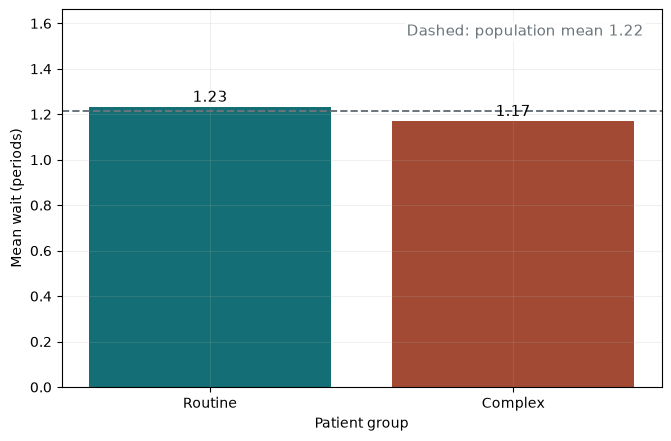

- **Scheduling:** First come, first served
- **Complex share of arrivals:** 0.25
- **Routine mean wait:** 1.23
- **Complex mean wait:** 1.17
- **Population mean wait:** 1.22
- **Equity gap:** 1.05
- **Patients never served:** 0

Population mean = 0.75 x 1.231 + 0.25 x 1.168 = 1.215. Gap = 1.231 / 1.168 = 1.05, close to a tie. 0 patients were still in the queue when the run ended.

In [5]:
show(policy_by_group(priority='fifo', complex_share=0.25))

**Use the idea.** Put the per-group table and the gap beside the aggregate in every comparison of scheduling or triage rules.

**Where the conclusion applies.** A teaching model: a batch is served at each period end, with fixed seed 5 and 18 arrivals a period. The ordering can change with other seeds or case mixes.

*Constructed example: the chapter's two-policy comparison and the stress-test case mixes, recomputed with the chapter's run and equity_gap functions.*

Every setting the interactive reader offers for this demonstration:

In [6]:
sweep(policy_by_group, [('priority', ['fifo', 'shortest_first']), ('complex_share', [0.1, 0.25, 0.5])])

- **priority = fifo, complex_share = 0.1**: Scheduling First come, first served; Complex share of arrivals 0.10; Routine mean wait 1.09; Complex mean wait 1.11; Population mean wait 1.09; Equity gap 1.02; Patients never served 10
- **priority = fifo, complex_share = 0.25**: Scheduling First come, first served; Complex share of arrivals 0.25; Routine mean wait 1.23; Complex mean wait 1.17; Population mean wait 1.22; Equity gap 1.05; Patients never served 0
- **priority = fifo, complex_share = 0.5**: Scheduling First come, first served; Complex share of arrivals 0.50; Routine mean wait 1.80; Complex mean wait 1.71; Population mean wait 1.75; Equity gap 1.05; Patients never served 10
- **priority = shortest_first, complex_share = 0.1**: Scheduling Shortest first; Complex share of arrivals 0.10; Routine mean wait 0.98; Complex mean wait 4.81; Population mean wait 1.36; Equity gap 4.92; Patients never served 26
- **priority = shortest_first, complex_share = 0.25**: Scheduling Shortest first; Complex share of arrivals 0.25; Routine mean wait 0.94; Complex mean wait 5.89; Population mean wait 2.18; Equity gap 6.29; Patients never served 49
- **priority = shortest_first, complex_share = 0.5**: Scheduling Shortest first; Complex share of arrivals 0.50; Routine mean wait 0.70; Complex mean wait 5.42; Population mean wait 3.06; Equity gap 7.74; Patients never served 41

## 2. The staffing rule swings and does not settle

*What does a staffing rule that scales its target from current staff do over sixty periods?*

The target is a multiple of current staff, so the rule has no fixed establishment to return to. A long wait raises staff, queues clear, and the next report is short, so staff falls again.

    equity_gap(outcome)

**Symbols and inputs.** Staff is the number of heads, between 4 and 30. Each period the target is current staff times the observed mean wait over the target wait of 1.0, and staff moves one adjustment time's fraction of the way.

**Predict first.** With adjustment time 4, does staff stay near its starting 10 or swing widely?

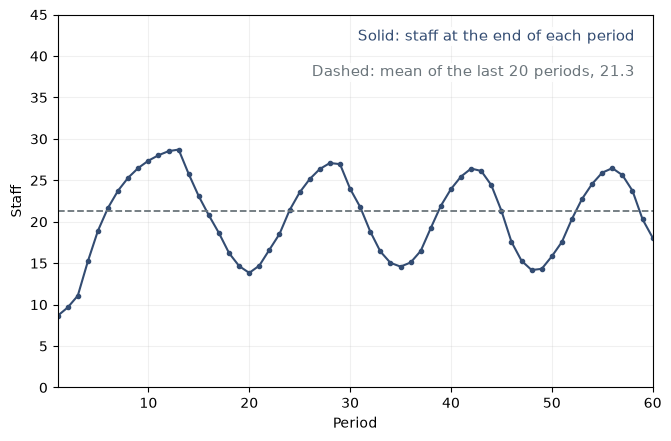

- **Scheduling:** First come, first served
- **Adjustment time:** 4
- **Lowest staff:** 8.6
- **Highest staff:** 28.7
- **Mean staff, last 20 periods:** 21.3
- **Patients never served:** 0

Each period moves staff by (target - staff) / 4. In period 1 staff went from 10.0 to 8.6468, so the target was 10.0 + 4 x (-1.3532) = 4.59 heads, a mean wait of 4.59 / 10.0 x 1.0 = 0.46. The rule asked for that many heads because the first period's served patients waited that long. Over the run staff swings from 8.6 to 28.7.

In [7]:
show(staffing_loop(priority='fifo', adjustment_time=4.0))

**Use the idea.** Anchor a staffing rule to a stated establishment and check whether the loop oscillates before reading the queue results.

**Where the conclusion applies.** Seed 5, 18 arrivals a period, and a rule that reads only the mean wait of the patients served. Adjustment times 2 and 8 are values defined for this reader, not printed in the chapter.

*Constructed example: the chapter's staffing run, with extra adjustment times defined for this reader, run with the chapter's run function.*

Every setting the interactive reader offers for this demonstration:

In [8]:
sweep(staffing_loop, [('priority', ['fifo', 'shortest_first']), ('adjustment_time', [2.0, 4.0, 8.0])])

- **priority = fifo, adjustment_time = 2.0**: Scheduling First come, first served; Adjustment time 2; Lowest staff 7.3; Highest staff 29.7; Mean staff, last 20 periods 19.5; Patients never served 26
- **priority = fifo, adjustment_time = 4.0**: Scheduling First come, first served; Adjustment time 4; Lowest staff 8.6; Highest staff 28.7; Mean staff, last 20 periods 21.3; Patients never served 0
- **priority = fifo, adjustment_time = 8.0**: Scheduling First come, first served; Adjustment time 8; Lowest staff 9.3; Highest staff 27.6; Mean staff, last 20 periods 20.0; Patients never served 0
- **priority = shortest_first, adjustment_time = 2.0**: Scheduling Shortest first; Adjustment time 2; Lowest staff 6.7; Highest staff 29.9; Mean staff, last 20 periods 22.6; Patients never served 19
- **priority = shortest_first, adjustment_time = 4.0**: Scheduling Shortest first; Adjustment time 4; Lowest staff 8.2; Highest staff 29.2; Mean staff, last 20 periods 17.7; Patients never served 49
- **priority = shortest_first, adjustment_time = 8.0**: Scheduling Shortest first; Adjustment time 8; Lowest staff 9.1; Highest staff 28.0; Mean staff, last 20 periods 20.9; Patients never served 26

## 3. A mean can hide the tail

*Does the group gap look the same on the mean and on the 90th percentile?*

Waits are skewed to the right, so the tail sits well above the mean. Shortest first stretches the complex group's tail most, and a mean-only report understates how long some patients wait.

    equity_gap(outcome)

**Symbols and inputs.** The 90th percentile wait is the value that 90 percent of a group's served patients waited no longer than. The gap is the worse group's value divided by the better group's.

**Predict first.** Under shortest first, is the complex group's 90th percentile wait above or below 1.5 times its mean?

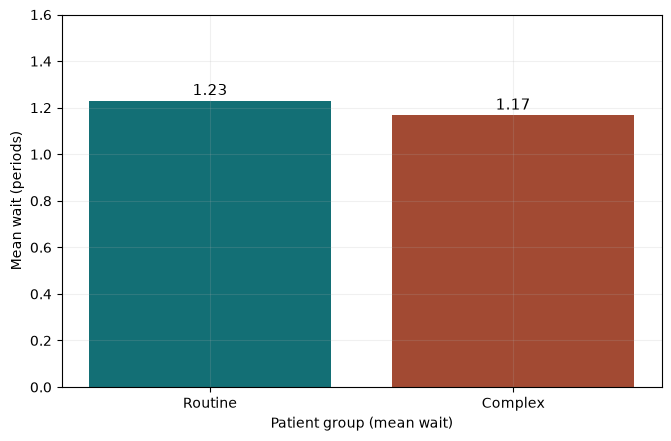

- **Scheduling:** First come, first served
- **Statistic shown:** Mean wait
- **Routine:** 1.23
- **Complex:** 1.17
- **Gap (worst over best):** 1.05
- **Complex 90th percentile:** 2.15

Gap on the mean wait = 1.231 / 1.168 = 1.05. The same run's complex 90th percentile is 2.15, so a report that shows only the mean leaves the other statistic out.

In [9]:
show(mean_versus_tail(statistic='mean', priority='fifo'))

**Use the idea.** Report a mean and a high percentile per group in the same row.

**Where the conclusion applies.** The percentile is the chapter's rule, the value at position int(0.9 x (n - 1)) in the sorted waits. A different percentile rule would shift the numbers slightly.

*Constructed example: the chapter's two scheduling runs, with the percentile column added from the chapter's run function.*

Every setting the interactive reader offers for this demonstration:

In [10]:
sweep(mean_versus_tail, [('statistic', ['mean', 'p90']), ('priority', ['fifo', 'shortest_first'])])

- **statistic = mean, priority = fifo**: Scheduling First come, first served; Statistic shown Mean wait; Routine 1.23; Complex 1.17; Gap (worst over best) 1.05; Complex 90th percentile 2.15
- **statistic = mean, priority = shortest_first**: Scheduling Shortest first; Statistic shown Mean wait; Routine 0.94; Complex 5.89; Gap (worst over best) 6.29; Complex 90th percentile 10.89
- **statistic = p90, priority = fifo**: Scheduling First come, first served; Statistic shown 90th percentile wait; Routine 2.24; Complex 2.15; Gap (worst over best) 1.04; Complex mean 1.17
- **statistic = p90, priority = shortest_first**: Scheduling Shortest first; Statistic shown 90th percentile wait; Routine 1.94; Complex 10.89; Gap (worst over best) 5.60; Complex mean 5.89

## 4. Stress the arrivals until a group disappears

*What happens to each group, and to the equity gap, as arrivals rise?*

Past capacity the queue grows. Shortest first always serves routine patients first, so when the queue never empties the complex group is never reached and has no mean wait to compare.

    equity_gap(outcome)
    prohibited_objectives()

**Symbols and inputs.** Arrivals per period are 12, 18, 24 or 36 over 60 periods. Served counts and the queue left at the end must add to all arrivals. A group with no served patients has no mean wait.

**Predict first.** With 36 arrivals and shortest first, how many complex patients are served?

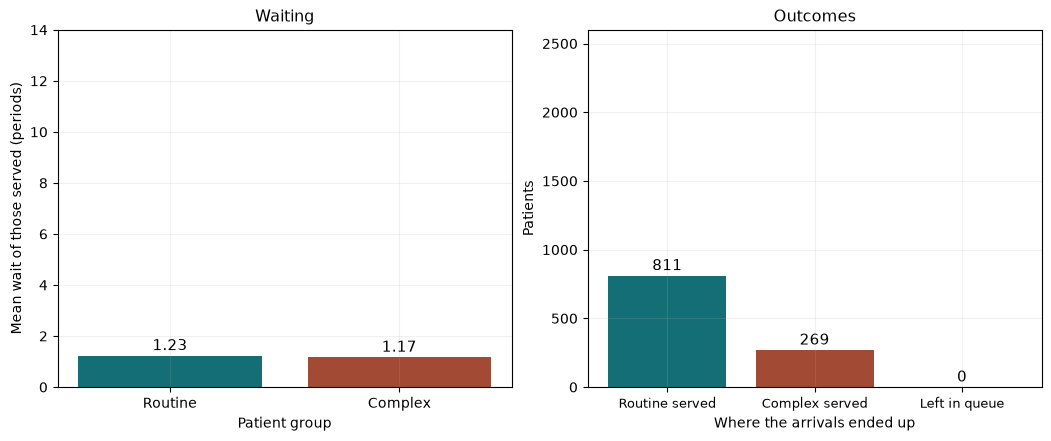

- **Arrivals per period:** 18
- **Scheduling:** First come, first served
- **Routine served:** 811
- **Complex served:** 269
- **Left in the queue:** 0
- **Equity gap:** 1.05

Arrivals = 18 x 60 = 1080. Served + left = 811 + 269 + 0 = 1080, so no patient is lost from the count. Gap = 1.231 / 1.168 = 1.05. First come, first served keeps the groups close.

In [11]:
show(arrival_stress(arrivals=18, priority='fifo'))

**Use the idea.** Run the overload case before trusting a scheduling rule, and report who is never served, not only who waits.

**Where the conclusion applies.** Arrivals scale in the chapter's way, rounded to whole patients, and staff is capped at 30. A model that lets staffing grow without bound would not reach this case.

*Constructed example: arrival rates defined for this reader around the chapter's 18, run with the chapter's run function.*

Every setting the interactive reader offers for this demonstration:

In [12]:
sweep(arrival_stress, [('arrivals', [12, 18, 24, 36]), ('priority', ['fifo', 'shortest_first'])])

- **arrivals = 12, priority = fifo**: Arrivals per period 12; Scheduling First come, first served; Routine served 542; Complex served 172; Left in the queue 6; Equity gap 1.05
- **arrivals = 12, priority = shortest_first**: Arrivals per period 12; Scheduling Shortest first; Routine served 546; Complex served 174; Left in the queue 0; Equity gap 9.35
- **arrivals = 18, priority = fifo**: Arrivals per period 18; Scheduling First come, first served; Routine served 811; Complex served 269; Left in the queue 0; Equity gap 1.05
- **arrivals = 18, priority = shortest_first**: Arrivals per period 18; Scheduling Shortest first; Routine served 811; Complex served 220; Left in the queue 49; Equity gap 6.29
- **arrivals = 24, priority = fifo**: Arrivals per period 24; Scheduling First come, first served; Routine served 1073; Complex served 345; Left in the queue 22; Equity gap 1.01
- **arrivals = 24, priority = shortest_first**: Arrivals per period 24; Scheduling Shortest first; Routine served 1092; Complex served 256; Left in the queue 92; Equity gap 7.12
- **arrivals = 36, priority = fifo**: Arrivals per period 36; Scheduling First come, first served; Routine served 1136; Complex served 374; Left in the queue 650; Equity gap 1.02
- **arrivals = 36, priority = shortest_first**: Arrivals per period 36; Scheduling Shortest first; Routine served 1510; Complex served 0; Left in the queue 650; Equity gap undefined (one group was never served, so it has no mean wait)

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

With waits of 0.94 routine and 5.89 complex and a quarter complex, what is the population mean?

<details><summary>Answer</summary>

0.75 x 0.94 + 0.25 x 5.89 = 0.705 + 1.4725 = 2.18.

</details>

### Exercise 2

If staff goes from 10 to 12 with adjustment time 4, what target did the rule set?

<details><summary>Answer</summary>

10 + 4 x (12 - 10) = 18 heads.

</details>

### Exercise 3

If the routine group waits 2.0 and the complex group 11.0 at the 90th percentile, what is the gap?

<details><summary>Answer</summary>

11.0 / 2.0 = 5.5.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/